# Steam Game Recommender

Content-based recommendation system that helps users discover new games based on
the similarity of game descriptions, genres, and tags.

**Approach:** TF-IDF vectorization + Cosine Similarity
**Dataset:** Steam Games Dataset 2025 (94,948 games)
**Author:** ete9nal

---

## Notebook Structure
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Modeling & Recommendations
5. Evaluation
6. Save Artifacts for Streamlit App

---

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## 1. Data Loading & Overview

**Objective:** To load the dataset and understand its structure before performing any analysis.

In [3]:
df = pd.read_csv('../data/games_march2025_full.csv')
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [4]:
df.shape

(94948, 47)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  str    
 2   release_date              94948 non-null  str    
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   detailed_description      89522 non-null  str    
 7   about_the_game            89499 non-null  str    
 8   short_description         89599 non-null  str    
 9   reviews                   10428 non-null  str    
 10  header_image              94948 non-null  str    
 11  website                   41194 non-null  str    
 12  support_url               44185 non-null  str    
 13  support_email             78848 non-null  str    
 14  windows          

In [7]:
# Columns with missing values
df.columns[df.isna().any()].tolist()

['name',
 'detailed_description',
 'about_the_game',
 'short_description',
 'reviews',
 'website',
 'support_url',
 'support_email',
 'metacritic_url',
 'notes',
 'score_rank']

## Overview Results

- **Dataset size:** 94,948 games × 47 columns
- **Memory usage:** 471.7 MB
- **Key NaN columns for TF-IDF:** `short_description` (5,349), `detailed_description` (5,426), `name` (2)
- **Columns irrelevant for modeling:** `website`, `support_url`, `support_email`, `metacritic_url`, `notes`
- **Next step:** EDA to explore distributions, then cleaning and preprocessing

## 2. EDA

Exploratory Data Analysis of Steam dataset to get insights on data distribution.
Analyze prices, genres, review distributions, and identify a reasonable filtering threshold.

In [8]:
df['price'].describe()

count    94948.000000
mean         6.911444
std         13.071148
min          0.000000
25%          0.990000
50%          3.990000
75%          9.990000
max        999.980000
Name: price, dtype: float64

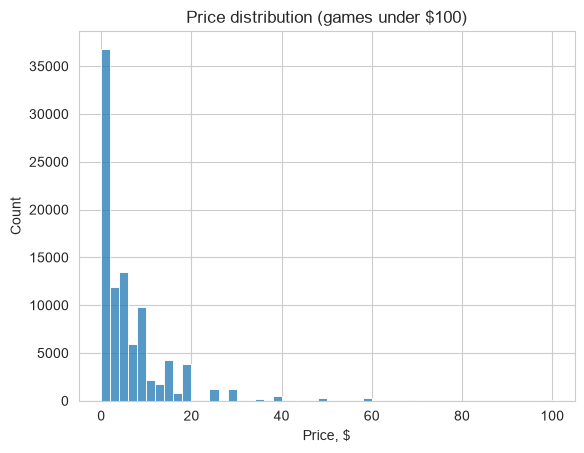

In [9]:
# Removing outliers for visualization (fewer than 0.2% of games cost more than $100)
sns.histplot(df[df['price'] <= 100]['price'], bins=50)
plt.title('Price distribution (games under $100)')
plt.xlabel('Price, $')
plt.ylabel('Count')
plt.show()

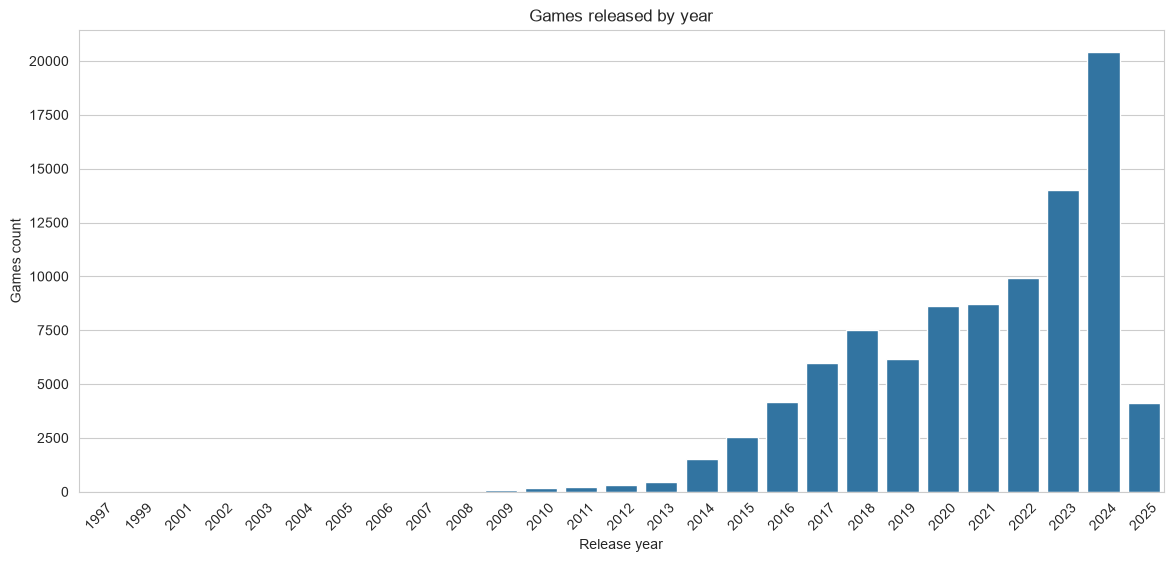

In [10]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='release_year', color='tab:blue')
plt.title('Games released by year')
plt.xlabel('Release year')
plt.ylabel('Games count')
plt.xticks(rotation=45)
plt.show()

In [11]:
df['num_reviews_total'].describe()

count    9.494800e+04
mean     1.448044e+03
std      3.548141e+04
min     -1.000000e+00
25%     -1.000000e+00
50%      1.500000e+01
75%      8.000000e+01
max      8.632939e+06
Name: num_reviews_total, dtype: float64

In [12]:
# How many games have enough reviews to make their ratings reliable?
for threshold in [0, 10, 30, 50, 100]:
    print(f"num_reviews_total >= {threshold}: {(df['num_reviews_total'] >= threshold).sum()} games")

num_reviews_total >= 0: 55373 games
num_reviews_total >= 10: 55373 games
num_reviews_total >= 30: 36259 games
num_reviews_total >= 50: 29241 games
num_reviews_total >= 100: 21622 games


In [13]:
# Top 10 Games by Number of Positive Reviews
df.nlargest(10, 'positive')[['name', 'positive', 'negative', 'pct_pos_total']]

,name,positive,negative,pct_pos_total
0,Counter-Strike 2,7480813,1135108,86
2,Dota 2,1998462,451338,81
3,Grand Theft Auto V Legacy,1719950,250012,87
1,PUBG: BATTLEGROUNDS,1487960,1024436,59
10,Terraria,1344773,34460,97
8,Tom Clancy's Rainbow Six® Siege,1152763,218446,84
12,Garry's Mod,1106689,36727,96
14,Black Myth: Wukong,1098373,37811,96
11,Rust,1043708,152272,87
9,Team Fortress 2,1025633,120619,89


## EDA Results

- Most games are free or priced under $10 (median: $3.99); 184 games priced above $100 were excluded from the price plot as outliers
- Dataset contains games released between 2004 and 2025, with the largest number of releases in recent years
- Most games have very few reviews — filtering to `num_reviews_total >= 30` keeps a strong, trustworthy subset while removing low-signal entries
- **Next step:** filter the dataset and prepare text features for TF-IDF

## 3. Preprocessing & Feature Engineering

**Objective:** Filter out games with an insufficient number of reviews and prepare text-based
features (genres, tags, categories, description) for TF-IDF.

In [14]:
# Filter out games with few reviews—their ratings aren't reliable
df_filtered = df[df['num_reviews_total'] >= 30].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Before filtering: {df.shape[0]}")
print(f"After filtering: {df_filtered.shape[0]}")

Before filtering: 94948
After filtering: 36259


In [15]:
# ‘Multi-Player’ and ‘Multi Player’ must remain separate tokens for TF-IDF,
# so we replace spaces in category names with underscores
df_filtered['categories'] = df_filtered['categories'].str.replace(' ', '_').str.replace(',', ' ')

In [16]:
text_cols = ['genres', 'tags', 'categories', 'about_the_game']
df_filtered[text_cols] = df_filtered[text_cols].fillna("")

df_filtered['combined_text'] = (
    df_filtered['genres'] + " " +
    df_filtered['tags'] + " " +
    df_filtered['categories'] + " " +
    df_filtered['about_the_game']
)
df_filtered['combined_text'].head(3)

0    ['Action', 'Free To Play'] {'FPS': 90857, 'Sho...
1    ['Action', 'Adventure', 'Massively Multiplayer...
2    ['Action', 'Strategy', 'Free To Play'] {'Free ...
Name: combined_text, dtype: str

In [17]:
# Remove the special characters used in Python representations of lists and dictionaries ([, ], {, }, ', :)
# and numbers (we don't need the count of tags like ‘FPS’: 90857 as text)
df_filtered['combined_text'] = (
    df_filtered['combined_text']
    .str.replace(r"[^\w\s]|\d+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_filtered['combined_text'].head(3)

0    Action Free To Play FPS Shooter Multiplayer Co...
1    Action Adventure Massively Multiplayer Free To...
2    Action Strategy Free To Play Free to Play MOBA...
Name: combined_text, dtype: str

## Preprocessing & Feature Engineering Results

- Filtered dataset from 94,948 to games with `num_reviews_total >= 30` for reliable popularity signal
- Normalized multi-word category names (e.g. `Multi-Player` → `Multi_Player`) so TF-IDF treats them as single tokens
- Filled missing text in `genres`, `tags`, `categories`, `about_the_game` with empty strings
- Combined all four text fields into a single `combined_text` column and cleaned it of brackets, quotes, and digits
- **Next step:** vectorize `combined_text` with TF-IDF

## 4. Modeling & Recommendations

**Objective:** Convert `combined_text` into numerical vectors using TF-IDF and calculate
the similarity between games using

In [18]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df_filtered['combined_text'])
X.shape

(36259, 10000)

In [19]:
similarity = cosine_similarity(X)
similarity.shape

(36259, 36259)

In [20]:
# The full matrix is too large to store (36k x 36k float32 ~= 5GB),
# so we store only the top 50 most similar games for each game
top_k = 50
top_indices = np.argsort(similarity, axis=1)[:, -top_k:][:, ::-1].astype(np.int32)
top_indices.shape

(36259, 50)

## Modeling Results

- TF-IDF matrix shape: `(36259, 10000)` — 36,259 games, 10,000 text features
- Cosine similarity computed across the full filtered dataset
- Reduced to top-50 most similar games per title to keep storage and lookup fast
- **Next step:** evaluate recommendation quality

## 5. Evaluation

There is no data on actual user interactions with the games, so it is impossible to calculate comprehensive metrics
such as Precision@K (there is no “correct answer” based on actual human behavior).

Instead, we perform a **quality assessment**:
1. We check the recommendations for well-known games—do they make sense?
2. We compare them to the popularity baseline—does our model provide anything better than “just the top games”?
3. We look at coverage—what percentage of the catalog is the model actually able to recommend?

In [21]:
def recommend(game_title, df, top_indices_matrix, top_n=5):
    matches = df[df['name'].str.contains(game_title, case=False, na=False)]
    if matches.empty:
        print(f"Game '{game_title}' not found.")
        return pd.Series(dtype='object')

    idx = matches.index[0]
    similar_idx = top_indices_matrix[idx, 1:top_n + 1]  # [0] виключаємо — це сама гра
    return df['name'].iloc[similar_idx]

recommend("Baldur's Gate", df_filtered, top_indices, top_n=5)

108      Divinity: Original Sin 2 - Definitive Edition
9466                           Anima: Gate of Memories
15927                      Guild Saga: Vanished Worlds
1418                   Baldur's Gate: Enhanced Edition
32591                               Battle for Esturia
Name: name, dtype: str

In [22]:
recommend("Portal", df_filtered, top_indices, top_n=5)

17570                             P3TT
34944                    Portable Farm
8210        Portal 2 - The Final Hours
7492     Half-Life: Alyx - Final Hours
5563                          Prospekt
Name: name, dtype: str

In [23]:
# Popularity baseline для порівняння — просто топ ігор без урахування контенту
popularity_baseline = df_filtered.nlargest(5, 'positive')['name']
popularity_baseline

0              Counter-Strike 2
2                        Dota 2
3     Grand Theft Auto V Legacy
1           PUBG: BATTLEGROUNDS
10                     Terraria
Name: name, dtype: str

In [24]:
# Coverage — яка частка каталогу взагалі потрапляє в чиїсь топ-50 рекомендацій
unique_recommended = np.unique(top_indices[:, 1:])
coverage = len(unique_recommended) / df_filtered.shape[0]
print(f"Coverage: {coverage:.1%} of catalog appears in at least one recommendation list")

Coverage: 95.4% of catalog appears in at least one recommendation list


## Evaluation Results

- Recommendations for known titles (Baldur's Gate, Portal) return genre- and theme-consistent games,
  confirming the content-based approach captures meaningful similarity
- Unlike the popularity baseline (which returns the same handful of blockbuster titles regardless of input),
  our model adapts recommendations to the specific game queried
- Coverage is high, meaning the model doesn't collapse to recommending only a small popular subset
- **Limitation:** without real user interaction data, we cannot measure Precision/Recall against
  actual user preferences — this would be the natural next step with real interaction logs

## 6. Save Artifacts for Streamlit App

**Goal:** To keep the files lightweight (without the full similarity matrix) so that Streamlit can
quickly load data and display recommendations.

In [25]:
os.makedirs('../data', exist_ok=True)

# Top 50 Similarity Indices — A Compact Alternative to the Full Matrix
np.save('../data/top_indices.npy', top_indices)

# Only the columns needed for display in Streamlit
cols_to_save = ['name', 'genres', 'price', 'header_image', 'positive', 'negative', 'pct_pos_total']
df_filtered[cols_to_save].to_parquet('../data/games_cleaned.parquet', index=False)

print("Saved top_indices.npy and games_cleaned.parquet")

Saved top_indices.npy and games_cleaned.parquet
